# ANALISIS EXPLORATORIO DE LOS DATOS TABULARES MID



In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from collections import Counter
import json
import os

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
data_MID = pd.read_excel("/content/drive/MyDrive/MID.xlsx")

Lo puntos a seguir:
1. Estructura el dataset
2. Calidad del corpus
3. Distribución de la información

# 1. Estructura general dataset tabular MID

## 1.1. Estudio general

Siguiendo pasos, vemos cual es la información general de los datos:

In [55]:
print("Tamaño del dataset tabular:", data_MID.shape)

Tamaño del dataset tabular: (192807, 20)


In [56]:
data_MID.head(5)

,NAME,LINK,CONTAINS,INTRODUCTION,USES,BENEFITS,SIDE_EFFECT,HOW_TO_USE,HOW_WORKS,QUICK_TIPS,CHEMICAL_CLASS,HABIT_FORMING,THERAPEUTIC_CLASS,ACTION_CLASS,SAFETY_ADVICE_TO_ALCOHOL,SAFETY_ADVICE_TO_PREGNANCY,SAFETY_ADVICE_TO_BREAST_FEEDING,SAFETY_ADVICE_TO_DRIVING,SAFETY_ADVICE_TO_KIDNEY,SAFETY_ADVICE_TO_LIVER
0,Andol 0.5mg Tablet,https://www.1mg.com/drugs/andol-0.5mg-tablet-6...,Haloperidol (0.5mg),Andol 0.5mg Tablet can also be used for treati...,Schizophrenia,Schizophrenia\nSchizophrenia is a mental disor...,Most side effects do not require any medical a...,Take this medicine in the dose and duration as...,Andol 0.5mg Tablet is a typical antipsychotic....,Andol 0.5mg Tablet helps treat schizophrenia.\...,Butyrophenone Derivative,No,NEURO CNS,Typical Antipsychotics,Andol 0.5mg Tablet may cause excessive drowsin...,Andol 0.5mg Tablet may be unsafe to use during...,Andol 0.5mg Tablet is probably unsafe to use d...,"Andol 0.5mg Tablet may decrease alertness, aff...",Andol 0.5mg Tablet is safe to use in patients ...,Andol 0.5mg Tablet should be used with caution...
1,Avastin 100mg Injection,https://www.1mg.com/drugs/avastin-100mg-inject...,Bevacizumab (100mg),\nAvastin 100mg Injection is an effective medi...,Cancer of colon and rectum \nNon-small cell...,Cancer of colon and rectum\nCancer of the colo...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Avastin 100mg Injection is a anti-angiogenic m...,"Avastin 100mg Injection is an effective, first...",Monoclonal antibody (mAb),No,ANTI NEOPLASTICS,Vascular endothelial growth factor (VEGF) inhi...,It is not known whether it is safe to consume ...,Avastin 100mg Injection may be unsafe to use d...,Avastin 100mg Injection is probably unsafe to ...,Avastin 100mg Injection may cause side effects...,Avastin 100mg Injection is probably safe to us...,Avastin 100mg Injection is probably safe to us...
2,Actorise 40 Injection,https://www.1mg.com/drugs/actorise-40-injectio...,Darbepoetin alfa (40mcg),Actorise 40 Injection is a medicine that needs...,Treatment of Anemia due to chronic kidney d...,Treatment of Anemia due to chronic kidney dise...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 40 Injection is an erythropoiesis-sti...,Actorise 40 Injection helps in the treatment o...,"Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA),It is not known whether it is safe to consume ...,Actorise 40 Injection may be unsafe to use dur...,Actorise 40 Injection is probably unsafe to us...,Actorise 40 Injection does not usually affect ...,Actorise 40 Injection is safe to use in patien...,Actorise 40 Injection should be used with caut...
3,Actorise 25 Injection,https://www.1mg.com/drugs/actorise-25-injectio...,Darbepoetin alfa (25mcg),Actorise 25 Injection is a medicine that needs...,Treatment of Anemia due to chronic kidney d...,Treatment of Anemia due to chronic kidney dise...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 25 Injection is an erythropoiesis-sti...,Actorise 25 Injection helps in the treatment o...,"Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA),It is not known whether it is safe to consume ...,Actorise 25 Injection may be unsafe to use dur...,Actorise 25 Injection is probably unsafe to us...,Actorise 25 Injection does not usually affect ...,Actorise 25 Injection is safe to use in patien...,Actorise 25 Injection should be used with caut...
4,Actorise 60 Injection,https://www.1mg.com/drugs/actorise-60-injectio...,Darbepoetin alfa (60mcg),Actorise 60 Injection is a medicine that needs...,Treatment of Anemia due to chronic kidney d...,Treatment of Anemia due to chronic kidney dise...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 60 Injection is an erythropoiesis-sti...,Actorise 60 Inje

In [65]:
print("Columnas del dataset:")
data_MID.columns = data_MID.columns.str.strip().str.lower() # se está normalizado el nombre de las columnas, es decir, eliminar espacios al principio y final, y pasar a minuscula
print(data_MID.columns.tolist())

print("\nTipos de datos:")
print(data_MID.dtypes)

print("\nInformación general:")
data_MID.info()

Columnas del dataset:
['name', 'link', 'contains', 'introduction', 'uses', 'benefits', 'side_effect', 'how_to_use', 'how_works', 'quick_tips', 'chemical_class', 'habit_forming', 'therapeutic_class', 'action_class', 'safety_advice_to_alcohol', 'safety_advice_to_pregnancy', 'safety_advice_to_breast_feeding', 'safety_advice_to_driving', 'safety_advice_to_kidney', 'safety_advice_to_liver']

Tipos de datos:
name                               object
link                               object
contains                           object
introduction                       object
uses                               object
benefits                           object
side_effect                        object
how_to_use                         object
how_works                          object
quick_tips                         object
chemical_class                     object
habit_forming                      object
therapeutic_class                  object
action_class                       object
safety

## 1.2. Duplicados

Para un entendimiento más exhaustivo del data set nos fijamos si existe duplicados, para ello:

In [66]:
print("Número total de filas enteras duplicadas:", data_MID.duplicated().sum()) # se mira si hay filas completads duplicadas. Lo que se hace es sumar los valores 'True'
print("Lo que representa:", round((data_MID.duplicated().sum()/data_MID.shape[0])*100, 2), "% de la data total")

Número total de filas enteras duplicadas: 41791
Lo que representa: 21.68 % de la data total


Podemos ver que existen muchas filas que están duplicadas, más especificamente casi un 22% son duplicadas. Ahora bien, se tiene que evaluar estos duplicados viendo si se trata de filas completamente idénticas (lo que se acaba de hacer), o si existe también un mismo medicamento con alguna columna distinta (dosis, formulación, o alguna descripción), para las cuales hay que decidir cómo trabajar con ellas.

Si se analiza las filas completamente idénticas como se ha hecho anteriormente:

In [67]:
conteo_filas_unicas = (data_MID.value_counts(dropna=False).reset_index(name="count")) #necesario no eliminar los valores nulos para tener los mismos datos que con la función "duplicated"

# Para que sea más fácil leer el dataframe donde se verá la fila repetida junto a su conteo se coloca esta columna tras el nombre y no como la última del dataframe creado:
cols = list(conteo_filas_unicas.columns)
cols.insert(1, cols.pop(cols.index("count")))
conteo_filas_unicas = conteo_filas_unicas[cols]

# Se ordena alfabéticamente según el nombre para que sea más cómodo de seguir:
conteo_filas_unicas = conteo_filas_unicas.sort_values(by="name")

#Se toman solo las filas que están duplicadas enteramente:
conteo_filas_duplicadas = conteo_filas_unicas[conteo_filas_unicas["count"] > 1]

print("Filas duplicadas en su totalidad:", conteo_filas_duplicadas.shape[0])
print("Las repeticiones son:", conteo_filas_duplicadas["count"].sum()- conteo_filas_duplicadas.shape[0], ", es decir, lo mismo que visto anteriormente", data_MID.duplicated().sum())

conteo_filas_duplicadas.head(5)

Filas duplicadas en su totalidad: 36544
Las repeticiones son: 41791 , es decir, lo mismo que visto anteriormente 41791


,name,count,link,contains,introduction,uses,benefits,side_effect,how_to_use,how_works,...,chemical_class,habit_forming,therapeutic_class,action_class,safety_advice_to_alcohol,safety_advice_to_pregnancy,safety_advice_to_breast_feeding,safety_advice_to_driving,safety_advice_to_kidney,safety_advice_to_liver
36525,A 250 Suspension,2,https://www.1mg.com/drugs/a-250-suspension-461277,Paracetamol (250mg),A 250 Suspension is given orally preferably at...,Pain relief \nTreatment of Fever,Pain relief\nA 250 Suspension is a common pain...,A 250 Suspension does not pose serious side ef...,Take this medicine in the dose and duration as...,A 250 Suspension possesses analgesic (pain-rel...,...,P-Aminophenol Derivative,No,PAIN ANALGESICS,Analgesic & Antipyretic-PCM,NaN,NaN,NaN,NaN,A 250 Suspension should be used with caution i...,A 250 Suspension should be used with caution i...
1748,A Cef 2gm Injection,3,https://www.1mg.com/drugs/a-cef-2gm-injection-...,Ceftriaxone (2gm),A Cef 2gm Injection may also be used to preven...,Treatment of Bacterial infections,Treatment of Bacterial infections\nA Cef 2gm I...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,A Cef 2gm Injection is an antibiotic. It kills...,...,Broad Spectrum (Third & fourth generation ceph...,No,ANTI INFECTIVES,Cephalosporins,Consuming alcohol with A Cef 2gm Injection doe...,A Cef 2gm Injection is safe to use during preg...,A Cef 2gm Injection should be used with cautio...,"A Cef 2gm Injection may decrease alertness, af...",A Cef 2gm Injection is safe to use in patients...,A Cef 2gm Injection should be used with cautio...
36534,A Cold Suspension,2,https://www.1mg.com/drugs/a-cold-suspension-44...,Cetirizine (5mg)+ Paracetamol (500mg)+ Pseudoe...,A Cold Suspension is taken with or without foo...,Treatment of Common cold,Treatment of Common cold\nA Cold Suspension is...,Most side effects do not require any medical a...,Take this medicine in the dose and duration as...,A Cold Suspension is a combination of three me...,...,NaN,No,RESPIRATORY,NaN,It is unsafe to consume alcohol with A Cold Su...,Information regarding the use of A Cold Suspen...,A Cold Suspension is probably safe to use duri...,A Cold Suspension does not usually affect your...,A Cold Suspension should be used with caution ...,A Cold Suspension is probably safe to use in p...
36535,A Pain Plus 100mg/325mg/250mg Tablet,2,https://www.1mg.com/drugs/a-pain-plus-100mg-32...,Aceclofenac (100mg)+ Paracetamol (325mg)+ Chlo...,A Pain Plus 100mg325mg250mg Tablet can be take...,Treatment of Muscular pain/,Treatment of Muscular pain\nA Pain Plus 100mg/...,Most side effects do not require any medical a...,Take this medicine in the dose and duration as...,A Pain Plus 100mg/325mg/250mg Tablet is a comb...,...,NaN,No,PAIN ANALGESICS,NaN,It is not known whether it is safe to consume ...,Information regarding the use of A Pain Plus 1...,Information regarding the use of A Pain Plus 1...,A Pain Plus 100mg/325mg/250mg Tablet may cause...,There is limited information available on the ...,There is limited information available on the ...
36521,A To Z Cream,2,https://www.1mg.com/drugs/a-to-z-cream-619960,Clobetasol (0.05% w/w)+ Neomycin (0.5% w/w)+ M...,A To Z Cream is only meant for external use an...,Treatment of Skin infections,Treatment of Skin infections\nA To Z Cream hel...,Most side effects do not require any medical a...,This medicine is for external use only. Use it...,A To Z Cream is a combination of four medicine...,...,NaN,No,DERMA,NaN,"No interaction found/established,imageAltTextA...",A To Z Cream may be unsafe to use during pregn...,A To Z Cream is probably safe to use during br...,NaN,NaN,NaN


Como se ha visto la cantidad de ruido duplicado que existe en el dataset, se decide eliminar las repiticiones:

In [68]:
data_MID_wo_dup = data_MID.drop_duplicates()

Para hacer más hincapie en las repiticiones de datos, pasamos a analizar si, al no tener en cuenta alguna columna, podemos ver más duplicados. Por ejemplo, se debe quitar la columna 'link', pues no aporta información relevante:

In [69]:
data_MID_wo_dup.drop(columns=['link'], inplace=True)

/tmp/ipykernel_924/3613581801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_MID_wo_dup.drop(columns=['link'], inplace=True)


In [70]:
print("Número total de filas enteras duplicadas al quitar la columna link:", data_MID_wo_dup.duplicated().sum())

Número total de filas enteras duplicadas al quitar la columna link: 2735


Se vuelve a tener filas completamente idénticas, al no contar con la columna  link. Es decir, se ha podido detectar instancias donde lo único que cambiaba era el URL. Por tanto, al no aporta nada relevante esa columna, se debe volver a eliminar estas duplicados exactos:

In [71]:
data_MID_wo_dup = data_MID_wo_dup.drop_duplicates()

In [72]:
print("Actualmente, el dataset tiene el siguiente tamaño:", data_MID_wo_dup.shape)

Actualmente, el dataset tiene el siguiente tamaño: (148281, 19)


## 1.3. Duplicados no identicos - Redundancia semática

### 1.3.1 Mismo nombre

Teniendo en cuenta esto, se pasa a investigar si hay medicamentos repetidos donde exista información diferente en alguna de las columnas. Para ello tomamos la columna 'name' como referencia:

In [73]:
# Se coge la columna "name" para ver los medicamentos que puedan estar repetidos:

medicine_rep = data_MID_wo_dup["name"].duplicated().sum()
print("Medicamentos repetidos por nombre:", medicine_rep) # Vemos cuántos medicamentos están repetidos

cont_names = data_MID_wo_dup["name"].value_counts()
repeated_names = cont_names[cont_names > 1].sort_values(ascending=False) # Vemos cuántas veces aparecen cuando el medicamento está repetido (contando con la primera vez)
print("\nTop nombres repetidos:")
print(repeated_names.head(20))


Medicamentos repetidos por nombre: 409

Top nombres repetidos:
name
Ringer Lactate Infusion    3
NS 0.9% Infusion           3
Xylovin Nasal Drops        3
Silcoll Cream              2
Melbild Solution           2
Momoz Cream                2
Citiclav Dry Syrup         2
Sucral MU Ointment         2
Acidale Oral Suspension    2
Chymotrip Tablet           2
Intaflam Syrup             2
Lodep 25mg Tablet          2
Emflox 200mg Tablet        2
Hungry Syrup               2
Minokem-N 5% Solution      2
Ahabir Tablet              2
Aerotrop-F Capsule         2
Lupisulide P Tablet        2
Lulimac Cream              2
Nodep 20mg Capsule         2
Name: count, dtype: int64


Tomando como ejemplo uno de los que más aparece:

In [74]:
ejemplo = data_MID_wo_dup[data_MID_wo_dup["name"]=="Ringer Lactate Infusion"]
display(ejemplo)

,name,contains,introduction,uses,benefits,side_effect,how_to_use,how_works,quick_tips,chemical_class,habit_forming,therapeutic_class,action_class,safety_advice_to_alcohol,safety_advice_to_pregnancy,safety_advice_to_breast_feeding,safety_advice_to_driving,safety_advice_to_kidney,safety_advice_to_liver
143689,Ringer Lactate Infusion,Sodium Chloride (0.600gm)+ Sodium Lactate (0.3...,Ringer Lactate Infusion is given as an injecti...,Short term fluid replacement after trauma/,Short term fluid replacement after trauma\nApp...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Ringer Lactate Infusion is a combination of fo...,Ringer Lactate Infusion is used to provide you...,NaN,No,BLOOD RELATED,NaN,It is unsafe to consume alcohol with Ringer La...,Ringer Lactate Infusion may be unsafe to use d...,Information regarding the use of Ringer Lactat...,"Not relevant, as Ringer Lactate Infusion is in...",Ringer Lactate Infusion should be used with ca...,Ringer Lactate Infusion is probably safe to us...
143911,Ringer Lactate Infusion,Sodium Chloride (0.6gm)+ Sodium Lactate (0.32g...,Ringer Lactate Infusion is given as an injecti...,Short term fluid replacement after trauma/,Short term fluid replacement after trauma\nApp...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Ringer Lactate Infusion is a combination of fo...,Ringer Lactate Infusion is used to provide you...,NaN,No,BLOOD RELATED,NaN,It is unsafe to consume alcohol with Ringer La...,Ringer Lactate Infusion may be unsafe to use d...,Information regarding the use of Ringer Lactat...,"Not relevant, as Ringer Lactate Infusion is in...",Ringer Lactate Infusion should be used with ca...,Ringer Lactate Infusion is probably safe to us...
145567,Ringer Lactate Infusion,Sodium Chloride (600mg)+ Sodium Lactate (320mg...,Ringer Lactate Infusion is given as an injecti...,Short term fluid replacement after trauma/,Short term fluid replacement after trauma\nApp...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Ringer Lactate Infusion is a combination of fo...,Ringer Lactate Infusion is used to provide you...,NaN,No,BLOOD RELATED,NaN,It is unsafe to consume alcohol with Ringer La...,Ringer Lactate Infusion may be unsafe to use d...,Information regarding the use of Ringer Lactat...,"Not relevant, as Ringer Lactate Infusion is in...",Ringer Lactate Infusion should be used with ca...,Ringer Lactate Infusion is probably safe to us...


Se puede ver a simple vista, que la diferencia que existe entre las distintas versiones del mismo medicamento es la forma de describir su composición. Por ejemplo, en el primer y segundo ejemplo la composición viene en gramos (gm es una abreviación de gramos) escribiendo '0.600gm' en el primero, y '0.6gm' en el segundo, lo que viene a ser lo mismo. En tercero, esta cantidad se da en miligramos '600mg'.

Por esto, aunque es cierto que solo existen 409 medicinas repetidas (frente al dataset de 148281 instancias), se decide hacer una función donde se facilite las diferencias entre las instancias de un mismo medicamento para ver si son siempre muy pequeñas.

Esta función nos dará las columnas que se modifican entre las filas con el mismo nombre del medicamento:

In [75]:
def columnas_distintas(medicina):
    diferencias = []
    for col in medicina.columns:
      if medicina[col].nunique() > 1:
        diferencias.append(col)
    return diferencias

In [76]:
variaciones = {}

for medicina, grupo in data_MID_wo_dup.groupby("name"):
    if len(grupo) > 1: # Tomando solo ese grupo de medicinas que se repiten
      variaciones[medicina] = columnas_distintas(grupo)

list(variaciones.items())[:5]

[('ART Eye Drop',
  ['contains',
   'introduction',
   'benefits',
   'side_effect',
   'how_to_use',
   'how_works',
   'quick_tips',
   'safety_advice_to_driving']),
 ('Acenac-MR Tablet',
  ['contains',
   'introduction',
   'benefits',
   'side_effect',
   'how_to_use',
   'how_works',
   'quick_tips',
   'safety_advice_to_driving']),
 ('Acidale Oral Suspension',
  ['contains',
   'introduction',
   'uses',
   'benefits',
   'side_effect',
   'how_to_use',
   'how_works',
   'quick_tips',
   'therapeutic_class',
   'safety_advice_to_kidney',
   'safety_advice_to_liver']),
 ('Acifit-DSR Capsule',
  ['contains',
   'introduction',
   'uses',
   'benefits',
   'side_effect',
   'how_to_use',
   'how_works',
   'quick_tips',
   'safety_advice_to_breast_feeding',
   'safety_advice_to_liver']),
 ('Aciloc 150 Tablet', ['side_effect'])]

In [77]:
variaciones["Ringer Lactate Infusion"] # para comprobar lo que se había intuido de que el cambio solo estaba en la columna 'contains' con la fomra de escribir las cantidades

['contains']

In [78]:
ejemplo = data_MID_wo_dup[data_MID_wo_dup["name"]=="Aciloc 150 Tablet"] # se toma este ejemplo que ha salido el último en la celda anterior y que solo tiene un cambio en una de sus columna
print(ejemplo["side_effect"].iloc[0])
print(ejemplo["side_effect"].iloc[1])

Most side effects do not require any medical attention and disappear as your body adjusts to the medicine. Consult your doctor if they persist or if you’re worried about them
Common side effects of Aciloc 150 Tablet
Headache
Diarrhea
Gastrointestinal disturbance

Most side effects do not require any medical attention and disappear as your body adjusts to the medicine. Consult your doctor if they persist or if you’re worried about them
Common side effects of Aciloc
Headache
Diarrhea
Gastrointestinal disturbance



Parece que cuando la cantidad de columnas es poca, los cambios son muy sutiles. Es decir, tomando como ejemplo "Aciloc 150 Tablet", y "Ringer Lactate Infusion", la diferencia es mínima y se pueden hasta considerar duplicados. Sin embargo, para los otros 4 ejemplos que se ha mostrado, el número de columnas variables son muchas, e internartemente es superior el cambio (no se muestra ahora, pero se ha visto distintas composiciones, distintos trucos, y efectos secundarios, por poner un ejemplo).

Se intenta confirmar esta teoría creando una nueva función, donde no solo se muestren las columnas cambiantes en las distintas instancias de un mismo medicamento, sino que se muestre además el texto de la columna para hacer una comparación minuciosa. En este caso, se trata los casos con 1 o 2 columnas variadas, para ver que esta diferencia es mínima.

In [79]:
def diferencias_columnas(medicina):
    diferencias_text_colum = {}
    for col in medicina.columns:
        text_unico = medicina[col].dropna().unique()

        if len(text_unico) > 1:
            diferencias_text_colum[col] = list(text_unico)

    return diferencias_text_colum

In [80]:
variaciones_sutiles = {}

for medicina, grupo in data_MID_wo_dup.groupby("name"):
    if len(grupo) > 1:
        dif = diferencias_columnas(grupo)
        if 1 <= len(dif) <= 2:  # En este caso, solo se seleccionan los medicamentos donde cambian una o dos columnas
            variaciones_sutiles[medicina] = dif
print(f"Existen {len(variaciones_sutiles)} medicinas repetidas con cambios muy sutiles entre sus diferentes instancias\n\n")
list(variaciones_sutiles.items())[:5]

Existen 174 medicinas repetidas con cambios muy sutiles entre sus diferentes instancias




[('Aciloc 150 Tablet',
  {'side_effect': ['Most side effects do not require any medical attention and disappear as your body adjusts to the medicine. Consult your doctor if they persist or if you’re worried about them\nCommon side effects of Aciloc 150 Tablet\nHeadache\nDiarrhea\nGastrointestinal disturbance\n',
    'Most side effects do not require any medical attention and disappear as your body adjusts to the medicine. Consult your doctor if they persist or if you’re worried about them\nCommon side effects of Aciloc\nHeadache\nDiarrhea\nGastrointestinal disturbance\n']}),
 ('Aerotrop-F Capsule',
  {'safety_advice_to_breast_feeding': ['Aerotrop-F Capsule is probably safe to use during breastfeeding. Limited human data suggests that the drug does not represent any significant risk to the baby.Monitor the baby for dry mouth, constipation, and urinary problems., label: SAFE IF PRESCRIBED,',
    'Aerotrop-F Capsule is probably safe to use during breastfeeding. Limited human data suggests

En estos 5 ejemplos se puede ver que los cambios son muy sutiles. Por ejemplo:
- "Common side effects of Aciloc 150 Tablet" vs "Common side effects of Aciloc"
- "label: SAFE IF PRESCRIBED, " vs "label: SAFE IF PRESCRIBED"
- "label: CONSULT YOUR DOCTOR," vs "label: CONSULT YOUR DOCTOR"
- "Abiraterone Acetate (500mg)" vs "Abiraterone Acetate (250mg)"
- "Common side effects of Allegra 120mg Tablet" vs "Common side effects of Allegra"

 Por tanto, se observa que muchos de estos casos se trata de simples comas que se pueden eliminar con una previa normalización del texto, o que, simplemente, se escribe el nombre del producto entero. En otros casos, se puede ver que el contenido cambia, lo cual es relevante. Aun así, el peso de estos casos de duplicación es muy irrelevante, pues son solo 174.

 Para intentar eliminar parte de estos duplicados eficientemente, se hace una simple normalización del texto:

In [81]:
print("Comprobación de que no queda ninguna fila completamente identica repetida en el dataset:", data_MID_wo_dup.duplicated().sum())

Comprobación de que no queda ninguna fila completamente identica repetida en el dataset: 0


In [82]:
def clean_text(text):
    if pd.isna(text):
        return text

    text = str(text).lower() # Pasar a minusculas

    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore') # Normaliza el texto, eliminando acentos y caracteres raros

    text = re.sub(r'[^a-z0-9\s\.]', '', text) # elimina puntación que no sea el punto o espacio

    text = re.sub(r'\s+', ' ', text).strip() # Elimina espacios, saltos de linea

    return text

In [83]:
cols_to_clean = data_MID_wo_dup.select_dtypes(include=['object']).columns.tolist()

for col in cols_to_clean:

    if col in data_MID_wo_dup.columns:
        data_MID_wo_dup[col] = data_MID_wo_dup[col].apply(clean_text)

In [84]:
print("Comprobación de si existe ahora alguna fila completamente identica repetida en el dataset:", data_MID_wo_dup.duplicated().sum())

Comprobación de si existe ahora alguna fila completamente identica repetida en el dataset: 42


Como se ha visto, con esta simple normalización, algunos de los cambios sutiles entre instancias han sido eliminados. En consecuencia, se elimina los duplicados una vez más:

In [85]:
data_MID_wo_dup = data_MID_wo_dup.drop_duplicates()

Para seguir con este estudio, se pensó en realizar una vectorización simple del texto (previo a un futuros embeddings), como con TFIDF Vectorizer, para estudiar la similitud de filas con el mismo nombre de medicinas con 'cosine_similarity'. Sin embargo, como se ha podido ver que algunos de estos cambios sutiles podrían dar valores altos de similitud, y a la vez, pueden ser relevantes en su significado, como por ejemplo, la cantidad de principio activo, se decide no proceder.

Se decide estudiar que columnas son las que generan más variación, para ver si esta información es importante:

In [86]:
from collections import Counter

cambios = []

for cols in variaciones.values():
    cambios.extend(cols)

conteo = Counter(cambios)
print(conteo)

Counter({'contains': 200, 'side_effect': 158, 'introduction': 131, 'safety_advice_to_breast_feeding': 115, 'quick_tips': 102, 'how_works': 100, 'benefits': 94, 'uses': 74, 'safety_advice_to_liver': 61, 'safety_advice_to_kidney': 60, 'safety_advice_to_driving': 51, 'safety_advice_to_pregnancy': 46, 'how_to_use': 34, 'safety_advice_to_alcohol': 27, 'therapeutic_class': 18, 'chemical_class': 13, 'action_class': 7, 'habit_forming': 1})


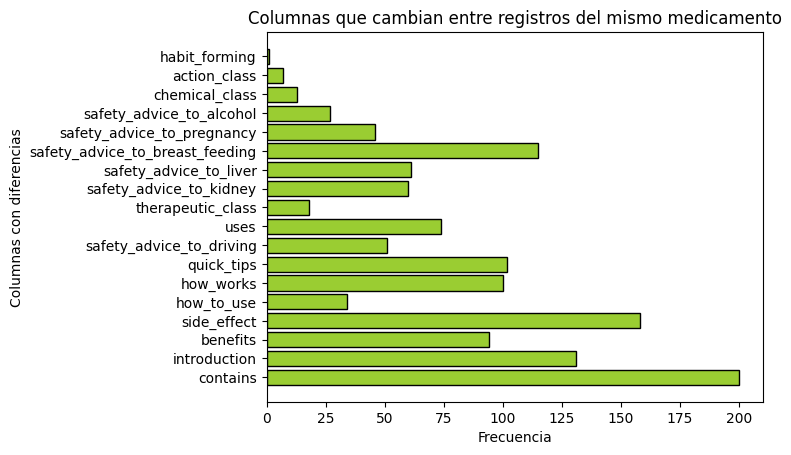

In [87]:
categorias = list(conteo.keys())
frecuencias = list(conteo.values())

plt.barh(categorias, frecuencias, color="yellowgreen", edgecolor="black")
plt.xlabel("Frecuencia")
plt.ylabel("Columnas con diferencias")
plt.title("Columnas que cambian entre registros del mismo medicamento")
plt.show()

Se puede ver que la mayoría de las variaciones entre distintas intancias del mismo medicamento se trata de cambios en el contenido, o en los efectos secundarios, o en el efecto en la lactancia, es decir, en columnas que no es texto secundario de los medicamentos. Por tanto, es importante no tratarlos como duplicados inútiles, y dejarlos como instancias indepedientes.

Además, como se ve que la mayoria de los cambios se produce en el contenido de los medicamentos con el mismo nombre, se estudia si solo cambia en cantidad (dosis) o también el principio activo:

In [88]:
data_MID_wo_dup.groupby("contains")["name"].nunique().sort_values(ascending=False).head(10)

,name
contains,
pantoprazole 40mg,1635
levocetirizine 5mg montelukast 10mg,1512
domperidone 30mg rabeprazole 20mg,1451
domperidone 30mg pantoprazole 40mg,1169
ofloxacin 200mg ornidazole 500mg,1054
aceclofenac 100mg paracetamol 325mg serratiopeptidase 15mg,1024
ofloxacin 200mg,1005
rabeprazole 20mg,962
aceclofenac 100mg paracetamol 325mg,914


Se puede ver que hay un desbalance en la aparición de los fármacos. Hay algunos que aparecen muchísimo como el pantoprazole, 1635 veces, mientras que cefpodoxime tan solo 908 medicinas lo contienen.

En conclusión, se ha podido ver en esta primera parte del analisis exploratorio del dataset que, aproximadamente el 22% de las filas eran duplicadas. Sin embargo, gracias a eliminar la columna 'link', que resultaba irrelevante, normalizar el texto y eliminar las filas duplicadas en su totalidad, se eliminó incluso algo más de ese 22%.

También se vió que existia un pequeño porcentaje de instancias con el mismo nombre del medicamento (en concreto, 409), pero que varían en ciertas características como el contenido o los efectos secundarios. Por tanto, se puede decir que se representa el mismo medicamento con dosis o formulación distintas. Dado que en farmacología la dosis puede modificar significativamente las indicaciones y efectos secundarios de un medicamento, se decidió mantener estas variantes como registros independientes. Esto resulta además beneficioso para el sistema de recuperación semántica (RAG), ya que permite recuperar información más específica cuando la consulta del usuario incluye una dosis concreta.

### 1.3.2 Misma raiz en el nombre

Sin embargo, para ahondar más en medicamentos con el mismo nombre, se toma aquellos con mismo nombre pero donde se indica una dosis o formulación distinta. De estos, se estudia como previamente la similitud del resto de sus columnas. Es decir, se ha visto que existen medicamentos con ditintos nombres ('name') pero que, a efectos prácticos, es la misma medicina, como por ejemplo: Ibuprofen 200mg, ibuprofen 400mg, ibuprofen 600mg...
Aunque se ha dicho que la dosis puede afectar a los efectos secundarios, usos o beneficios, se quiere evaluar la redundancia semática que puede haber en estos casos, lo cual justaficaría una vez más el uso de embeddings y del posterior FAISS que se hará.

In [89]:
# Primero se agrupan todos los medicamentos según la raiz de su columna 'name', es decir, según la primera palabra de su nombre

data_MID_wo_dup["raiz"] =(data_MID_wo_dup['name'].str.lower().str.split().str[0]) # por si acaso, se pasa a minuscula, se separan las palabras, y se coge la primera

display(pd.DataFrame(data_MID_wo_dup["raiz"].unique())) # se mira si las raices obtenidas tienen sentido
print(len(data_MID_wo_dup["raiz"].unique()))

,0
0,andol
1,avastin
2,actorise
3,azel
4,azacytin
...,...
93487,zabesta
93488,zedoxy
93489,zonticin
93490,zitelmih


93492


In [90]:
# Para comprobar que los medicamentos se agrupan debidamente.
resultados_raiz = []
grupos_raiz = data_MID_wo_dup.groupby("raiz")
for raiz, grupo in grupos_raiz:
    if len(grupo) > 1:
        resultados_raiz.append({
            "raiz": raiz,
            "n_medicamentos": len(grupo),
            "medicamentos": grupo["name"].tolist()})

df_resultados_raiz = pd.DataFrame(resultados_raiz)
print(df_resultados_raiz.shape)
df_resultados_raiz.head(10)

(27478, 3)


,raiz,n_medicamentos,medicamentos
0,a,24,"[a kare combipack, a ret hc cream, a mox 125mg..."
1,a2b,2,"[a2b a 40 mg5 mg tablet, a2b 80mg tablet]"
2,a2d,2,"[a2d capsule, a2d tablet]"
3,ab,23,"[ab phylline n tablet, ab phylline capsule, ab..."
4,abamlo,2,"[abamlo 5 tablet, abamlo 2.5mg tablet]"
5,abastin,2,"[abastin m 10mg10mg tablet, abastin 10mg tablet]"
6,abaxis,2,"[abaxis 2.5mg tablet, abaxis 5mg tablet]"
7,abclopid,2,"[abclopid 75 tablet, abclopid a 75 capsule]"
8,abd,3,"[abd plus tablet, abd plus syrup, abd 200mg sy..."
9,abdrot,2,"[abdrot plus tablet, abdrot 80mg tablet]"


Haciendo una lectura rápida se puede ver que esta agrupación tiene sentido en parte. Se puede observar agrupaciones donde se habla del mismo medicamento en diferente dosis o en distintas fórmulas (tablet, injection, syrup, etc..). Pero se otras, donde la raiz es demasiado corta, y parece que las agrupaciones no cuadran. Por ejemplo:

In [91]:
df_resultados_raiz[df_resultados_raiz["raiz"].str.len() < 3].head(10)

,raiz,n_medicamentos,medicamentos
0,a,24,"[a kare combipack, a ret hc cream, a mox 125mg..."
3,ab,23,"[ab phylline n tablet, ab phylline capsule, ab..."
34,ac,14,"[ac para 100mg325mg tablet, ac 100mg tablet, a..."
276,ad,7,"[ad 100mg capsule, ad 10mg sachet, ad para 100..."
322,af,8,"[af kit tablet, af 150 tablet dt, af 400 table..."
336,ag,2,"[ag 500mg tablet, ag para plus 100mg325mg15mg ..."
367,al,3,"[al ketocer shampoo, al 5mg tablet, al won plu..."
569,am,6,"[am dopa 250mg tablet, am laqer nail lacquer, ..."
736,an,2,"[an 500 500mg tablet, an mic 500mg injection]"
819,ap,6,"[ap 100mg325mg tablet, ap fast sp tablet, ap f..."


Se ve que existen agrupaciones que no se hacen por medicamentos, sino por farmaceuticas (marca, laboratorio, prefijo comercial...), lo cual no es  lo que se buscaba. Se pasa a agrupar por raiz de nombre del medicamento, y raiz del principio activo:

In [92]:
data_MID_wo_dup["raiz_ppio"] = (data_MID_wo_dup["contains"].str.lower().str.split().str[0])

In [93]:
resultados_raiz_ppio = []
grupos_raiz_ppio = data_MID_wo_dup.groupby(["raiz", "raiz_ppio"])
for (raiz, principio), grupo in grupos_raiz_ppio:

    if len(grupo) > 1:
        resultados_raiz_ppio.append({
            "raiz": raiz,
            "principio_activo": principio,
            "n_medicamentos": len(grupo),
            "medicamentos": grupo["name"].tolist()})
df_raiz_ppio = pd.DataFrame(resultados_raiz_ppio)
df_raiz_ppio.sample(20, random_state=5)

,raiz,principio_activo,n_medicamentos,medicamentos
19001,rumatin,aceclofenac,4,"[rumatin p 100 mg500 mg tablet, rumatin sp 100..."
456,alonac,aceclofenac,5,"[alonac tc 100mg4mg tablet, alonac p 100mg650m..."
8885,halodryl,haloperidol,2,"[halodryl 1.5mg2mg tablet, halodryl forte tablet]"
8964,havodills,levosalbutamolambroxolguaifenesin,2,"[havodills oral drops, havodills syrup raspber..."
14940,nitro,nitrofurantoin,2,"[nitro f 100mg tablet, nitro uti 100mg tablet]"
12191,levokast,levocetirizine,3,"[levokast tablet, levokast kid tablet, levokas..."
23305,vomisave,ondansetron,3,"[vomisave syrup, vomisave 4 tablet dt, vomisav..."
20862,thiorelax,thiocolchicoside,2,"[thiorelax 4mg tablet, thiorelax 8mg tablet]"
22400,venish,venlafaxine,4,"[venish 37.5mg tablet, venish sr 75 tablet, ve..."
10941,kace,aceclofenac,2,"[kace 100mg500mg tablet, kace s 100mg500mg15mg..."


Parece que de esta manera, la agrupación es más lógica. Ahora se verá si con esta agrupación existe verdadera diferencias entre las distintas columnas:

In [94]:
data_MID_wo_dup.groupby(["raiz","raiz_ppio"])["name"].count().sort_values(ascending=False).head(10) # Se ve cuantos de cada tipo existen

,,name
raiz,raiz_ppio,
l,levocetirizine,64
glimisave,glimepiride,36
it,itraconazole,28
novamox,amoxycillin,23
mox,amoxycillin,23
o,ofloxacin,22
lc,levocetirizine,22
oflo,ofloxacin,20
zifi,cefixime,20


Aunque sigue existiendo estas raices cortas, provenientes de las farmaceuticas, existe, al menos, una nueva agrupación. Como hicimos anteriormente:

In [95]:
def diferencias_columnas(grupo):
    diferencias = []
    for col in grupo.columns:

        if col in ["name","raiz","raiz_ppio"]:
            continue
        #nos fijamos en el resto de columnas
        if grupo[col].nunique() > 1:
            diferencias.append(col)

    return diferencias

In [107]:
variaciones_raiz_ppio = {}
for (raiz, principio), grupo in grupos_raiz_ppio:

    if len(grupo) > 1:
        dif = diferencias_columnas(grupo)
        if dif:
            variaciones_raiz_ppio[(raiz,principio)] = dif

In [110]:
list(variaciones_raiz_ppio.items())[:5]

[(('a', 'aceclofenac'),
  ['contains',
   'introduction',
   'uses',
   'benefits',
   'side_effect',
   'how_to_use',
   'how_works',
   'quick_tips',
   'safety_advice_to_alcohol',
   'safety_advice_to_pregnancy',
   'safety_advice_to_breast_feeding',
   'safety_advice_to_driving',
   'safety_advice_to_kidney',
   'safety_advice_to_liver',
   'combined_text']),
 (('a', 'doxycycline'),
  ['contains',
   'introduction',
   'uses',
   'benefits',
   'side_effect',
   'how_to_use',
   'how_works',
   'quick_tips',
   'safety_advice_to_alcohol',
   'safety_advice_to_pregnancy',
   'safety_advice_to_breast_feeding',
   'safety_advice_to_driving',
   'safety_advice_to_kidney',
   'safety_advice_to_liver',
   'combined_text']),
 (('a', 'pantoprazole'),
  ['introduction',
   'uses',
   'benefits',
   'side_effect',
   'how_to_use',
   'how_works',
   'quick_tips',
   'safety_advice_to_alcohol',
   'safety_advice_to_pregnancy',
   'safety_advice_to_breast_feeding',
   'safety_advice_to_driving

In [109]:
print(len(variaciones))

24524


Por tanto, aunque en un primer momento se puede llegar a pensar que existe redundancia semántica entre medicamentos del mismo grupo, se puede ver que existe una gran variación entre estos. Se confirma, pues, que el hecho de que se cambie de dosis o formulación afecta a los efectos secudnarios o su efecto en la lactancia, entre otros. Por tanto, no hay excesiva rendundancia semantica.

## 2. Calidad de los datos/corpus
Como se indicó al principio, el segundo paso de este análisis exploratorio es evaluar la calidad del corpus. Para ello, se indagará algo más en la información interna de cada una de las columnas.

## 2.1. Valores nulos
Una vez entendidos los duplicados, pasamos a estudiar los valores nulos dentro del dataset:

In [103]:
nulos = data_MID_wo_dup.isnull().sum().sort_values(ascending=False)
nulo_porcentaje = (data_MID_wo_dup.isnull().mean() * 100).sort_values(ascending=False)

resumen_nulos = pd.DataFrame({
    "numero de nulos": nulos,
    "porcentaje de nulos (%)": nulo_porcentaje.round(2)
})

display(resumen_nulos)

,numero de nulos,porcentaje de nulos (%)
action_class,82486,55.64
chemical_class,70403,47.49
safety_advice_to_driving,15721,10.61
safety_advice_to_liver,11317,7.63
safety_advice_to_kidney,11315,7.63
introduction,9583,6.46
safety_advice_to_pregnancy,7307,4.93
safety_advice_to_breast_feeding,7307,4.93
safety_advice_to_alcohol,7304,4.93
quick_tips,1142,0.77


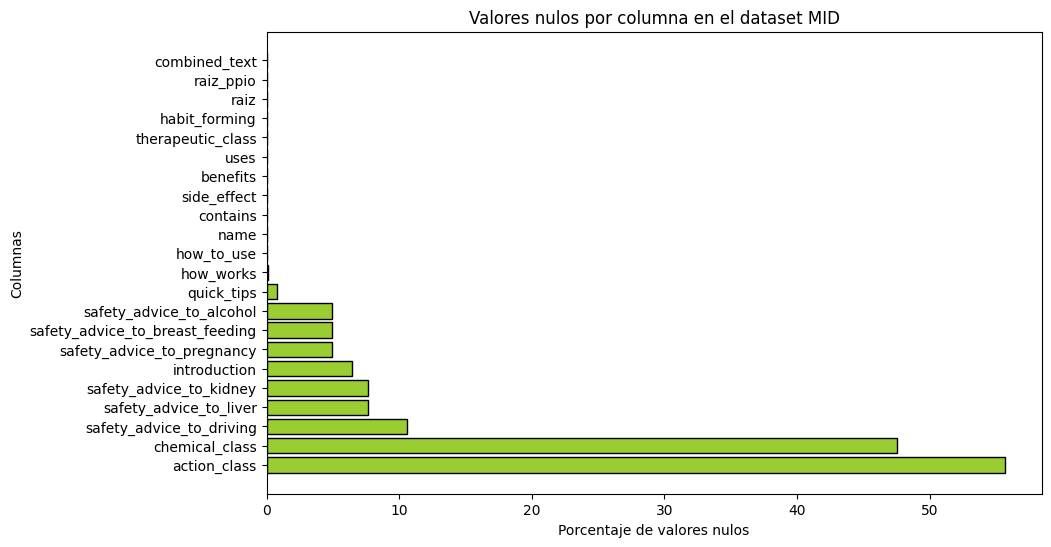

In [104]:
plt.figure(figsize=(10,6))

plt.barh( resumen_nulos.index, resumen_nulos["porcentaje de nulos (%)"], color="yellowgreen", edgecolor="black")
plt.xlabel("Porcentaje de valores nulos")
plt.ylabel("Columnas")
plt.title("Valores nulos por columna en el dataset MID")
plt.show()

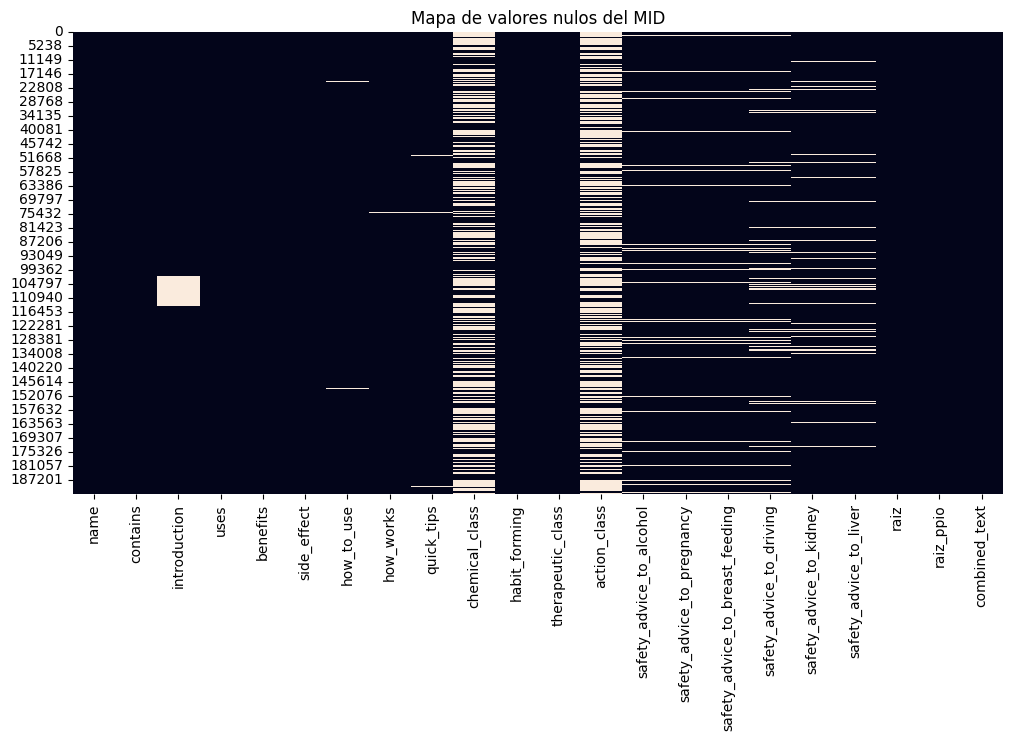

In [105]:
plt.figure(figsize=(12,6))
sns.heatmap(data_MID_wo_dup.isnull(), cbar=False)
plt.title("Mapa de valores nulos del MID")
plt.show()

Se puede ver tanto en la tabla como el heatmap, que existen dos columnas con un gran porcentaje de nulos, llegando hasta la mitad de la totalidad. El resto de características tienen como máximo un 10% de valores nulos, por lo que no tiene importancia, y pueden ser imputados.

Aunque se ha hecho una búsqueda de valores nulos, y se ha podido ver que estos existen en el dataset, se realiza ahora un analisis en profundidad, por si encontraramos 'falsos valores nulos' que incluyan ruido en el dataset.

In [106]:
nom_column = data_MID_wo_dup.select_dtypes(include=["object"]).columns.tolist()

posibles_nan = [
    "",
    " ",
    "unknown",
    "not available",
    "no information",
    "no information available",
    "n/a",
    "na",
    "none",
    "-",
    "without information",
    "there is no information",
    "no info"] # pensando en todas las posibles combinaciones en ingles

report_posibles_nan = []
for col in nom_column:
    texto = data_MID_wo_dup[col]
    falsos_nulos = texto[texto.isin(posibles_nan)]
    conteo = (falsos_nulos.replace("", "[vacio]").replace(" ", "[espacio]").value_counts())
    porcentaje= round((len(falsos_nulos) / len(data_MID_wo_dup))*100, 2)

    report_posibles_nan.append({
        "column": col,
        "numero de falsos nulos": len(falsos_nulos),
        "porcentaje de falsos nulos (%)": porcentaje,
        "tipos detectados": conteo.to_dict()})

report_posibles_nan = pd.DataFrame(report_posibles_nan).sort_values(by="porcentaje de falsos nulos (%)", ascending=False)
(report_posibles_nan)

,column,numero de falsos nulos,porcentaje de falsos nulos (%),tipos detectados
10,habit_forming,179,0.12,{'[vacio]': 179}
3,uses,68,0.05,{'[vacio]': 68}
1,contains,0,0.00,{}
2,introduction,0,0.00,{}
4,benefits,0,0.00,{}
0,name,0,0.00,{}
5,side_effect,0,0.00,{}
6,how_to_use,0,0.00,{}
8,quick_tips,0,0.00,{}
7,how_works,0,0.00,{}


De esta manera, podemos ver que existen, juntos a los valores nulos reales existentes,  lo que podemos llamar "valores nulos falsos", que solo representan una cantidad mínima en la totalidad de los datos. Para poder hacer uso de todos estos valores nulos, se deben imputar. Asimismo, como aunque existen dos columnas con una mayoría de valores nulos, al no llegar estas a un 70%, se decide mantenerlas.

Por tanto, como se hará después se decide rellenar los nulos con un "no information available" y dejar los falsos nulos como estás al ser un porcentaje casi invisible.

In [122]:
data_MID_wo_dup = data_MID_wo_dup.fillna("no information available")

## 2.2. Longitud del texto

Otro punto a estudiar es la variación de longitud entre las distintas columnas. De esta manera, se puede detectar cual de ellas son más pobres, si existe algun tipo de asimetria o de outliers textuales. Para ello:

In [111]:
columnas_texto= data_MID_wo_dup.select_dtypes(include="object").columns

In [120]:
estad_longitud = {}

for col in columnas_texto:
    longitudes = data_MID_wo_dup[col].dropna().astype(str).apply(len)
    estad_longitud[col] = {
        "mean": longitudes.mean(),
        "median": longitudes.median(),
        "max": longitudes.max()}

datos_longitudes = pd.DataFrame(estad_longitud).T

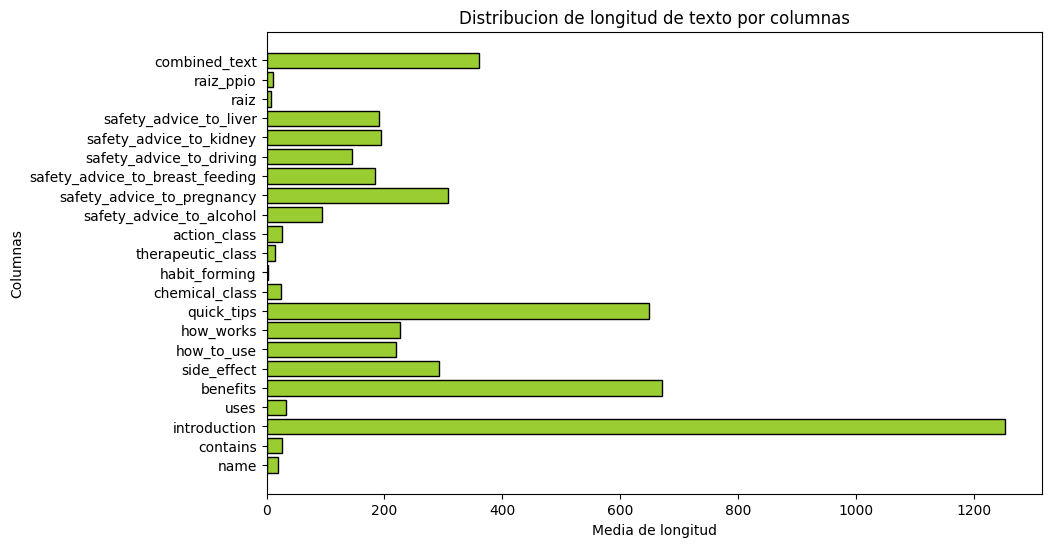

In [121]:
plt.figure(figsize=(10,6))

plt.barh(datos_longitudes.index,  datos_longitudes["median"],color="yellowgreen", edgecolor="black")
plt.xlabel("Media de longitud")
plt.ylabel("Columnas")
plt.title("Distribucion de longitud de texto por columnas")
plt.show()

El análisis de longitud textual muestra que varias columnas contienen descripciones extensas, especialmente introduction, benefits y quick_tips, lo cual tiene sentido. Esto sugiere que el corpus proporciona suficiente contexto semántico para generar embeddings informativos y permitir una recuperación relevante mediante similitud semántica.